# Descriptive profile

This section describes the observed national country-year values for the primary Eurostat outcome.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
outputs_dir = PROJECT_ROOT / 'outputs'
processed_dir = PROJECT_ROOT / 'data' / 'processed'

outcome = pd.read_csv(processed_dir / 'country_year_outcome.csv')
outcome_08b = pd.read_csv(processed_dir / 'country_year_outcome_08b.csv')
outcome.head()

,geo,year,unmet_need_pc,status
0,AL,2017,13.1,NaN
1,AL,2018,14.8,NaN
2,AL,2019,14.6,NaN
3,AL,2020,10.6,NaN
4,AL,2021,10.7,NaN


In [2]:
year_summary = pd.read_csv(outputs_dir / 'primary_year_summary.csv')
country_summary = pd.read_csv(outputs_dir / 'primary_country_summary.csv')
latest = pd.read_csv(outputs_dir / 'primary_latest_available_ranking.csv')
year_summary

,year,countries,mean_unmet_need_pc,median_unmet_need_pc,min_unmet_need_pc,p25_unmet_need_pc,p75_unmet_need_pc,max_unmet_need_pc
0,2008,31,3.442,1.70,0.2,0.700,5.300,15.3
1,2009,31,3.358,2.10,0.2,1.100,4.000,14.9
2,2010,33,3.970,1.90,0.1,1.100,5.200,16.4
3,2011,33,4.000,2.20,0.1,1.100,5.900,16.1
4,2012,33,3.870,2.30,0.1,1.300,5.700,12.4
5,2013,35,4.334,3.00,0.0,1.400,7.700,13.8
6,2014,35,4.126,3.30,0.1,1.350,6.300,12.5
7,2015,35,3.494,2.60,0.1,1.000,4.550,12.7
8,2016,35,3.023,2.30,0.2,0.850,3.450,15.3
9,2017,36,2.822,2.15,0.1,1.000,3.350,13.1


In [3]:
country_summary.head(10)

,geo,first_year,last_year,observed_years,mean_unmet_need_pc,median_unmet_need_pc,min_unmet_need_pc,max_unmet_need_pc
0,AL,2017,2023,7,12.043,10.70,10.2,14.8
1,EE,2008,2025,18,10.150,8.80,4.3,16.4
2,LV,2008,2025,18,8.972,8.30,4.0,16.1
3,EL,2008,2025,18,8.956,8.90,5.4,13.1
4,XK,2018,2019,2,7.600,7.60,5.2,10.0
5,RO,2008,2025,18,7.233,5.85,2.2,12.2
6,TR,2008,2025,18,6.383,3.40,0.7,16.4
7,PL,2008,2025,18,5.456,5.10,1.9,9.0
8,RS,2013,2025,13,5.369,5.00,2.8,8.7
9,BG,2008,2025,18,4.900,2.45,1.0,15.3


In [4]:
latest.head(10)

,geo,year,unmet_need_pc
0,EL,2025,11.5
1,AL,2023,10.3
2,FI,2025,7.8
3,EE,2025,7.7
4,LV,2025,7.6
5,XK,2019,5.2
6,UK,2018,4.5
7,FR,2025,3.7
8,LT,2025,3.3
9,SI,2025,3.2


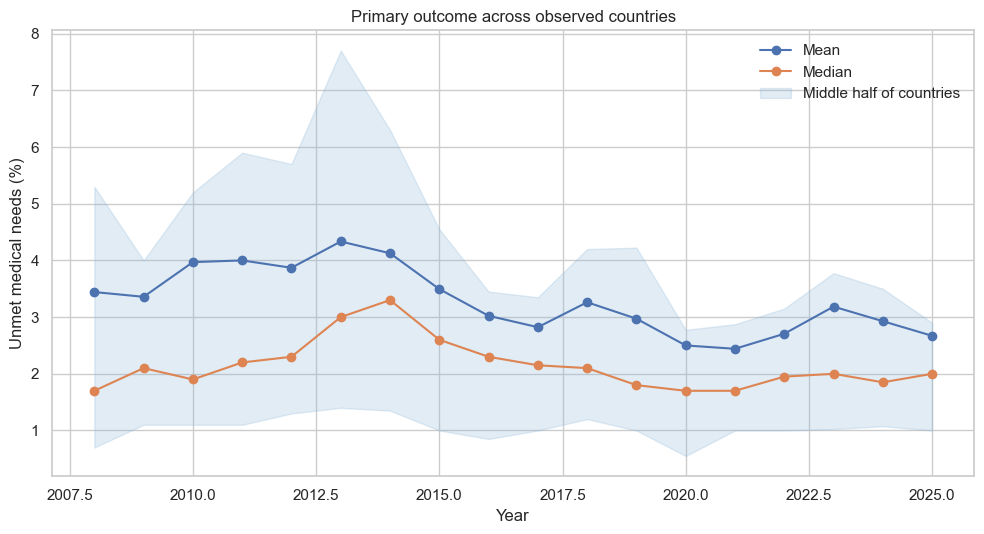

In [5]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 5.5))
plt.plot(year_summary['year'], year_summary['mean_unmet_need_pc'], marker='o', label='Mean')
plt.plot(year_summary['year'], year_summary['median_unmet_need_pc'], marker='o', label='Median')
plt.fill_between(
    year_summary['year'],
    year_summary['p25_unmet_need_pc'],
    year_summary['p75_unmet_need_pc'],
    color='#8bb6d9',
    alpha=0.25,
    label='Middle half of countries',
)
plt.xlabel('Year')
plt.ylabel('Unmet medical needs (%)')
plt.title('Primary outcome across observed countries')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [6]:
comparison = pd.read_csv(outputs_dir / 'primary_vs_08b_common_cells.csv')
comparison_summary = pd.read_csv(outputs_dir / 'primary_vs_08b_year_summary.csv')
comparison_summary

,year,countries,mean_primary_pc,mean_08b_pc,mean_difference_08b_minus_08,median_difference_08b_minus_08
0,2021,30,2.330,3.800,1.470,1.05
1,2022,31,2.516,3.958,1.442,0.80
2,2023,31,2.887,4.439,1.552,0.90
3,2024,32,2.928,4.484,1.556,1.00
4,2025,30,2.670,4.070,1.400,0.85


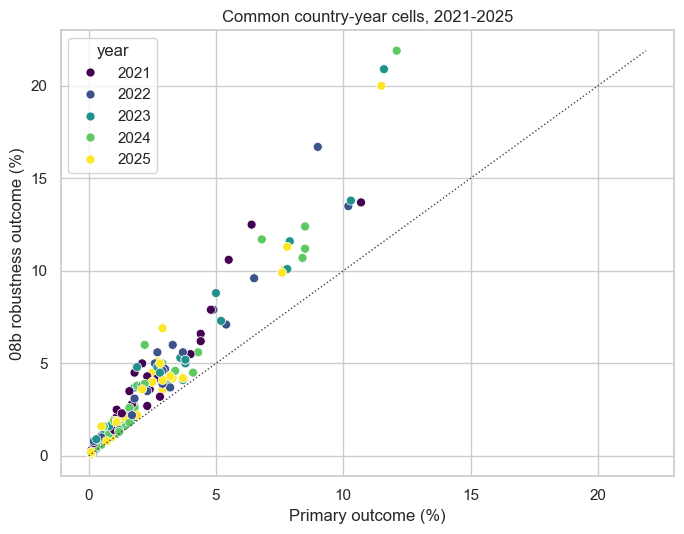

In [7]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(
    data=comparison,
    x='unmet_need_pc',
    y='unmet_need_08b_pc',
    hue='year',
    palette='viridis',
    s=42,
)
axis_max = max(comparison['unmet_need_pc'].max(), comparison['unmet_need_08b_pc'].max())
plt.plot([0, axis_max], [0, axis_max], color='#444444', linewidth=1, linestyle=':')
plt.xlabel('Primary outcome (%)')
plt.ylabel('08b robustness outcome (%)')
plt.title('Common country-year cells, 2021-2025')
plt.tight_layout()
plt.show()

The tables and figures describe observed values only. The two outcome definitions are kept separate.